# IndoBERT Sentiment Fine-Tuning Run 4 — Weighted Loss, Lower LR, and Slang Normalization


## Research Context
Run 1 had the highest accuracy but weak Neutral recall. Run 2 improved Neutral recall with weighted loss but reduced accuracy. Run 3 improved the trade-off using a lower learning rate.

Actual Run 1 results: accuracy `0.7416143987`, macro F1 `0.6926732992`, weighted F1 `0.7364500012`, Neutral precision `0.5638247763`, Neutral recall `0.4525519849`, Neutral F1 `0.5020973154`.

Actual Run 2 results: accuracy `0.7328197437`, macro F1 `0.7033754261`, weighted F1 `0.7403101705`, Neutral precision `0.4723702665`, Neutral recall `0.6366729679`, Neutral F1 `0.5423510467`.

Actual Run 3 results: accuracy `0.7362285247`, macro F1 `0.7093262951`, weighted F1 `0.7444675722`, Neutral precision `0.4770146025`, Neutral recall `0.6669187146`, Neutral F1 `0.5562036891`.

Run 4 tests conservative slang normalization to handle informal Indonesian Google Play reviews. This is an experiment, not a guaranteed final model.

## Experiment Setup
Run 4 writes to a separate Google Drive folder and must not overwrite previous run outputs.

In [ ]:
RUN_NAME = "run_4_weighted_loss_lr_1e-5_slang_norm"
RUN_1_NAME = "run_1_baseline"
RUN_2_NAME = "run_2_weighted_loss"
RUN_3_NAME = "run_3_weighted_loss_lr_1e-5"


## Environment Setup
Run this notebook in Google Colab with GPU runtime enabled. Package installation is intended for Colab only.

In [ ]:
!pip -q install torch transformers datasets evaluate accelerate scikit-learn pandas matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.2 MB/s eta 0:00:00


## GPU Check
Check CUDA availability and print the GPU name.

In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError("GPU runtime is required for Run 4 IndoBERT fine-tuning.")


CUDA available: True
GPU: Tesla T4


## Google Drive Mount
The base path is configured once through `DRIVE_PROJECT_DIR`. Run 4 outputs use separate `saved_model`, `checkpoints`, and `figures` directories.

In [ ]:
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

DRIVE_PROJECT_DIR = Path("/content/drive/MyDrive/SentiRank")
DATASET_DIR = DRIVE_PROJECT_DIR / "datasets" / "processed" / "indobert"
OUTPUT_DIR = DRIVE_PROJECT_DIR / "outputs" / "indobert" / RUN_NAME
FIGURE_DIR = OUTPUT_DIR / "figures"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
MODEL_OUTPUT_DIR = OUTPUT_DIR / "saved_model"
RUN_OUTPUT_DIRS = {
    RUN_1_NAME: DRIVE_PROJECT_DIR / "outputs" / "indobert" / RUN_1_NAME,
    RUN_2_NAME: DRIVE_PROJECT_DIR / "outputs" / "indobert" / RUN_2_NAME,
    RUN_3_NAME: DRIVE_PROJECT_DIR / "outputs" / "indobert" / RUN_3_NAME,
}

for output_path in [OUTPUT_DIR, FIGURE_DIR, CHECKPOINT_DIR, MODEL_OUTPUT_DIR]:
    output_path.mkdir(parents=True, exist_ok=True)

print("Run 4 output:", OUTPUT_DIR)
for run_name, run_output_dir in RUN_OUTPUT_DIRS.items():
    print(f"{run_name} output:", run_output_dir)


Mounted at /content/drive
Run 4 output: /content/drive/MyDrive/SentiRank/outputs/indobert/run_4_weighted_loss_lr_1e-5_slang_norm
run_1_baseline output: /content/drive/MyDrive/SentiRank/outputs/indobert/run_1_baseline
run_2_weighted_loss output: /content/drive/MyDrive/SentiRank/outputs/indobert/run_2_weighted_loss
run_3_weighted_loss_lr_1e-5 output: /content/drive/MyDrive/SentiRank/outputs/indobert/run_3_weighted_loss_lr_1e-5


## Dataset Paths
Expected input files in `DATASET_DIR`:
- `train.csv`
- `validation.csv`
- `test.csv`
- `label_mapping.json`

In [ ]:
TRAIN_FILE = DATASET_DIR / "train.csv"
VALIDATION_FILE = DATASET_DIR / "validation.csv"
TEST_FILE = DATASET_DIR / "test.csv"
LABEL_MAPPING_FILE = DATASET_DIR / "label_mapping.json"

for file_path in [TRAIN_FILE, VALIDATION_FILE, TEST_FILE, LABEL_MAPPING_FILE]:
    if not file_path.is_file():
        raise FileNotFoundError(f"Missing required input file: {file_path}")


## Dataset Loading and Validation
Required columns are `text_indobert`, `label_id`, and `final_sentiment`. Print dataset sizes and label distributions for train, validation, and test splits.

In [ ]:
import json
import random

import numpy as np
import pandas as pd

REQUIRED_COLUMNS = {"text_indobert", "label_id", "final_sentiment"}
EXPECTED_LABEL_MAPPING = {"Negative": 0, "Neutral": 1, "Positive": 2}

def load_split(path: Path, split_name: str) -> pd.DataFrame:
    data = pd.read_csv(path)
    missing_columns = REQUIRED_COLUMNS - set(data.columns)
    if missing_columns:
        raise ValueError(f"{split_name} is missing columns: {sorted(missing_columns)}")
    empty_text_count = data["text_indobert"].fillna("").astype(str).str.strip().eq("").sum()
    if empty_text_count:
        raise ValueError(f"{split_name} contains {empty_text_count} empty text rows")
    return data

train_df = load_split(TRAIN_FILE, "train")
validation_df = load_split(VALIDATION_FILE, "validation")
test_df = load_split(TEST_FILE, "test")
label_mapping = json.loads(LABEL_MAPPING_FILE.read_text(encoding="utf-8"))

if label_mapping != EXPECTED_LABEL_MAPPING:
    raise ValueError(f"Unexpected label mapping: {label_mapping}")

id2label = {label_id: label for label, label_id in label_mapping.items()}
label2id = label_mapping

print("Dataset sizes:")
print({"train": len(train_df), "validation": len(validation_df), "test": len(test_df)})

for split_name, data in {"train": train_df, "validation": validation_df, "test": test_df}.items():
    print(f"\n{split_name} label distribution")
    print(data["label_id"].map(id2label).value_counts().sort_index())


Dataset sizes:
{'train': 68446, 'validation': 14668, 'test': 14668}

train label distribution
label_id
Negative    27780
Neutral     12340
Positive    28326
Name: count, dtype: int64

validation label distribution
label_id
Negative    5953
Neutral     2644
Positive    6071
Name: count, dtype: int64

test label distribution
label_id
Negative    5953
Neutral     2645
Positive    6070
Name: count, dtype: int64


## Slang Normalization Utility Import
Run 4 uses the reusable `app.utils.slang_normalization` utility from the project code copied to Google Drive. The experiment input text column is `text_indobert_slang`, while the original `text_indobert` column is preserved.

In [ ]:
import sys
from pathlib import Path

DRIVE_PROJECT_DIR = Path("/content/drive/MyDrive/SentiRank")
sys.path.append(str(DRIVE_PROJECT_DIR / "ml-service"))

from app.utils.slang_normalization import normalize_slang_text, build_slang_replacement_summary


## Apply Slang Normalization
Create `text_indobert_slang` for each split. Do not overwrite `text_indobert`.

In [ ]:
for split_data in [train_df, validation_df, test_df]:
    split_data["text_indobert_slang"] = split_data["text_indobert"].apply(normalize_slang_text)

print("Run 4 uses text_indobert_slang for tokenization and training.")


Run 4 uses text_indobert_slang for tokenization and training.


## Slang Normalization Summary
Save total rows, changed rows, changed percentages, replacement counts, and sample before/after rows.

In [ ]:
def build_split_slang_summary(split_name: str, data: pd.DataFrame) -> tuple[dict, pd.DataFrame]:
    changed_mask = data["text_indobert"].fillna("").astype(str) != data["text_indobert_slang"].fillna("").astype(str)
    replacement_summary = build_slang_replacement_summary(data["text_indobert"].fillna("").astype(str).tolist())
    sample_columns = [column for column in ["external_id", "rating", "final_sentiment", "text_indobert", "text_indobert_slang"] if column in data.columns]
    samples = data.loc[changed_mask, sample_columns].head(30).copy()
    samples.insert(0, "split", split_name)
    summary = {
        "split": split_name,
        "total_rows": int(len(data)),
        "changed_rows": int(changed_mask.sum()),
        "changed_percentage": float(changed_mask.mean() * 100),
        "replacement_counts": replacement_summary["replacement_counts"],
        "top_replacement_counts": replacement_summary["top_replacement_counts"],
        "skipped_empty_target_count": replacement_summary["skipped_empty_target_count"],
        "skipped_risky_short_token_count": replacement_summary["skipped_risky_short_token_count"],
    }
    return summary, samples

split_summaries = []
sample_frames = []
for split_name, split_data in {"train": train_df, "validation": validation_df, "test": test_df}.items():
    summary, samples = build_split_slang_summary(split_name, split_data)
    split_summaries.append(summary)
    sample_frames.append(samples)

all_texts = pd.concat([train_df["text_indobert"], validation_df["text_indobert"], test_df["text_indobert"]], ignore_index=True)
aggregate_replacement_summary = build_slang_replacement_summary(all_texts.fillna("").astype(str).tolist())
slang_summary = {
    "run_name": RUN_NAME,
    "text_source_column": "text_indobert",
    "text_output_column": "text_indobert_slang",
    "split_summaries": split_summaries,
    "aggregate_replacement_summary": aggregate_replacement_summary,
    "methodology_note": "Conservative slang normalization preserves negation, stopwords, sentence structure, and emoji where possible.",
}
(OUTPUT_DIR / "indobert_slang_normalization_summary.json").write_text(
    json.dumps(slang_summary, indent=2, sort_keys=True), encoding="utf-8"
)
pd.concat(sample_frames, ignore_index=True).to_csv(OUTPUT_DIR / "indobert_slang_normalization_samples.csv", index=False)
slang_summary


{'run_name': 'run_4_weighted_loss_lr_1e-5_slang_norm',
 'text_source_column': 'text_indobert',
 'text_output_column': 'text_indobert_slang',
 'split_summaries': [{'split': 'train',
   'total_rows': 68446,
   'changed_rows': 46218,
   'changed_percentage': 67.52476404757036,
   'replacement_counts': {'asik': 519,
    'bgus': 432,
    'apk': 3259,
    'baguss': 720,
    'bangett': 310,
    'putar lagu': 539,
    'apa2': 168,
    'sampe': 570,
    'mau': 6042,
    'yg': 5191,
    'aja': 5132,
    'ga': 3586,
    'pencet': 289,
    'dlu': 763,
    'make': 255,
    'share': 244,
    'gabisa': 1306,
    'dm': 16,
    'denger': 1505,
    'dapet': 102,
    'dikit': 1343,
    'tapi': 7546,
    'doang': 678,
    'coba': 1892,
    'music': 923,
    'good': 1118,
    'update': 1895,
    'terus': 2031,
    'trus': 568,
    'save': 21,
    'memory': 17,
    'tambah': 643,
    'ngga': 489,
    'tuh': 462,
    'karna': 933,
    'hp': 591,
    'blm': 177,
    'bintang 5': 422,
    'aku': 4866,
    'kas

## Slang Normalization Sanity Check
Before training, inspect one before/after text example and print changed-row percentages plus conservative skip counters for every split.

In [ ]:
if not train_df.empty:
    sample_row = train_df.iloc[0]
    print("Sample original text_indobert:")
    print(sample_row["text_indobert"])
    print("\nSample normalized text_indobert_slang:")
    print(sample_row["text_indobert_slang"])

print("\nAggregate top replacement counts:")
print(slang_summary["aggregate_replacement_summary"]["top_replacement_counts"])
print("\nAggregate skipped empty-target count:")
print(slang_summary["aggregate_replacement_summary"]["skipped_empty_target_count"])
print("\nAggregate skipped risky short-token count:")
print(slang_summary["aggregate_replacement_summary"]["skipped_risky_short_token_count"])

for split_name, split_data in {"train": train_df, "validation": validation_df, "test": test_df}.items():
    changed_mask = split_data["text_indobert"].fillna("").astype(str) != split_data["text_indobert_slang"].fillna("").astype(str)
    split_summary = next(summary for summary in split_summaries if summary["split"] == split_name)
    print(f"{split_name} changed rows: {int(changed_mask.sum())} / {len(split_data)} ({changed_mask.mean() * 100:.2f}%)")
    print(f"{split_name} skipped empty-target count: {split_summary['skipped_empty_target_count']}")
    print(f"{split_name} skipped risky short-token count: {split_summary['skipped_risky_short_token_count']}")


Sample original text_indobert:
asik banget

Sample normalized text_indobert_slang:
menyenangkan banget

Aggregate top replacement counts:
{'tapi': 10764, 'mau': 8695, 'aja': 7433, 'yg': 7359, 'aku': 6879, 'gak': 6806, 'ga': 5102, 'udah': 4771, 'kalo': 4685, 'apk': 4629, 'malah': 4373, 'makin': 3711, 'kasih': 3370, 'gk': 3314, 'terus': 2909, 'update': 2699, 'coba': 2667, 'pake': 2628, 'dengerin': 2559, 'download': 2352, 'ga bisa': 2329, 'bayar': 2281, 'dengerin lagu': 2261, 'gw': 2232, 'beli': 2207, 'denger': 2198, 'udh': 2080, 'bgt': 1940, 'dikit': 1929, 'klo': 1892}

Aggregate skipped empty-target count:
361

Aggregate skipped risky short-token count:
361
train changed rows: 46218 / 68446 (67.52%)
train skipped empty-target count: 241
train skipped risky short-token count: 262
validation changed rows: 9934 / 14668 (67.73%)
validation skipped empty-target count: 57
validation skipped risky short-token count: 48
test changed rows: 9817 / 14668 (66.93%)
test skipped empty-target count: 6

## Class Weight Calculation
Calculate class weights from the train split using `compute_class_weight(class_weight="balanced")`. Expected train distribution is Negative `27780`, Neutral `12340`, Positive `28326`.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1, 2])
train_labels = train_df["label_id"].astype(int).to_numpy()
weights = compute_class_weight(class_weight="balanced", classes=classes, y=train_labels)
class_weights_tensor = torch.tensor(weights, dtype=torch.float)
class_weights_payload = {
    "run_name": RUN_NAME,
    "method": "sklearn.utils.class_weight.compute_class_weight(class_weight='balanced')",
    "train_distribution": train_df["label_id"].map(id2label).value_counts().sort_index().to_dict(),
    "weights_by_label": {id2label[int(label_id)]: float(weight) for label_id, weight in zip(classes, weights)},
    "weights_by_id": {str(int(label_id)): float(weight) for label_id, weight in zip(classes, weights)},
}

(OUTPUT_DIR / "indobert_class_weights.json").write_text(
    json.dumps(class_weights_payload, indent=2, sort_keys=True), encoding="utf-8"
)
class_weights_payload


{'run_name': 'run_4_weighted_loss_lr_1e-5_slang_norm',
 'method': "sklearn.utils.class_weight.compute_class_weight(class_weight='balanced')",
 'train_distribution': {'Negative': 27780,
  'Neutral': 12340,
  'Positive': 28326},
 'weights_by_label': {'Negative': 0.8212862970962324,
  'Neutral': 1.848892490545651,
  'Positive': 0.8054555296665019},
 'weights_by_id': {'0': 0.8212862970962324,
  '1': 1.848892490545651,
  '2': 0.8054555296665019}}

## Tokenization
Use `indobenchmark/indobert-base-p1`, `max_length = 128`, and `text_indobert_slang` as the training text column.

In [ ]:
from datasets import Dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

MODEL_NAME = "indobenchmark/indobert-base-p1"
MAX_LENGTH = 128
TEXT_COLUMN = "text_indobert_slang"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def to_hf_dataset(data: pd.DataFrame) -> Dataset:
    return Dataset.from_pandas(
        data[[TEXT_COLUMN, "label_id"]].rename(columns={TEXT_COLUMN: "text", "label_id": "labels"}),
        preserve_index=False,
    )

def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

train_dataset = to_hf_dataset(train_df).map(tokenize_batch, batched=True)
validation_dataset = to_hf_dataset(validation_df).map(tokenize_batch, batched=True)
test_dataset = to_hf_dataset(test_df).map(tokenize_batch, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/68446 [00:00<?, ? examples/s]

Map:   0%|          | 0/14668 [00:00<?, ? examples/s]

Map:   0%|          | 0/14668 [00:00<?, ? examples/s]

## Model Setup
Use `AutoModelForSequenceClassification` with `num_labels = 3`, `id2label`, and `label2id`.

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
)


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Custom Weighted Trainer
Override `compute_loss`, use weighted cross entropy, move class weights to the logits device, and preserve compatibility with Hugging Face Trainer kwargs.

In [ ]:
from transformers import Trainer

class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights_tensor: torch.Tensor, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights_tensor = class_weights_tensor

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels", None)
        if labels is None:
            raise ValueError("WeightedTrainer requires labels in inputs.")
        outputs = model(**inputs)
        logits = outputs["logits"] if isinstance(outputs, dict) else outputs.logits
        loss_function = torch.nn.CrossEntropyLoss(
            weight=self.class_weights_tensor.to(logits.device)
        )
        loss = loss_function(
            logits.view(-1, model.config.num_labels),
            labels.view(-1),
        )
        return (loss, outputs) if return_outputs else loss


model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

## Training Configuration
Run 4 config: model `indobenchmark/indobert-base-p1`, loss `weighted_cross_entropy`, text column `text_indobert_slang`, max length `128`, batch size `16`, learning rate `1e-5`, epochs `3`, random state `42`, epoch evaluation/save, best model by `f1_macro`, `load_best_model_at_end = True`, and `save_total_limit = 2`. If GPU memory is limited, use batch size `8` with `gradient_accumulation_steps = 2`.

In [ ]:
import inspect

from transformers import EarlyStoppingCallback, TrainingArguments

BATCH_SIZE = 16
GRADIENT_ACCUMULATION_STEPS = 1
LEARNING_RATE = 1e-5
EPOCHS = 3
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

training_argument_names = set(inspect.signature(TrainingArguments.__init__).parameters.keys())
strategy_key = "eval_strategy" if "eval_strategy" in training_argument_names else "evaluation_strategy"
training_kwargs = {
    "output_dir": str(CHECKPOINT_DIR),
    strategy_key: "epoch",
    "save_strategy": "epoch",
    "learning_rate": LEARNING_RATE,
    "per_device_train_batch_size": BATCH_SIZE,
    "per_device_eval_batch_size": BATCH_SIZE,
    "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
    "num_train_epochs": EPOCHS,
    "weight_decay": 0.01,
    "load_best_model_at_end": True,
    "metric_for_best_model": "f1_macro",
    "greater_is_better": True,
    "report_to": [],
    "seed": RANDOM_STATE,
}
if "logging_strategy" in training_argument_names:
    training_kwargs["logging_strategy"] = "epoch"
if "save_total_limit" in training_argument_names:
    training_kwargs["save_total_limit"] = 2

training_args = TrainingArguments(**training_kwargs)


## Metrics Function
Compute accuracy, macro precision, macro recall, macro F1, weighted precision, weighted recall, and weighted F1.

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_prediction):
    logits, labels = eval_prediction
    predictions = np.argmax(logits, axis=-1)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, predictions, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        labels, predictions, average="weighted", zero_division=0
    )
    return {
        "accuracy": float(accuracy_score(labels, predictions)),
        "precision_macro": float(precision_macro),
        "recall_macro": float(recall_macro),
        "f1_macro": float(f1_macro),
        "precision_weighted": float(precision_weighted),
        "recall_weighted": float(recall_weighted),
        "f1_weighted": float(f1_weighted),
    }


## Training
Use `WeightedTrainer`, save the best model, and print the best checkpoint, best metric, and final training runtime.

In [ ]:
trainer_argument_names = set(inspect.signature(Trainer.__init__).parameters.keys())
trainer_tokenizer_kwargs = (
    {"processing_class": tokenizer}
    if "processing_class" in trainer_argument_names
    else {"tokenizer": tokenizer}
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    class_weights_tensor=class_weights_tensor,
    **trainer_tokenizer_kwargs,
)

train_result = trainer.train()
trainer.save_model(str(MODEL_OUTPUT_DIR))
tokenizer.save_pretrained(str(MODEL_OUTPUT_DIR))

print("Best checkpoint:", trainer.state.best_model_checkpoint)
print("Best metric:", trainer.state.best_metric)
print("Final training runtime:", train_result.metrics.get("train_runtime"))


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted
1,0.743090,0.697110,0.722525,0.686134,0.694851,0.687211,0.741023,0.722525,0.729579
2,0.646041,0.712623,0.723412,0.689986,0.700164,0.690693,0.744957,0.723412,0.731159
3,0.575498,0.732794,0.732274,0.692883,0.699858,0.695031,0.742102,0.732274,0.736268


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best checkpoint: /content/drive/MyDrive/SentiRank/outputs/indobert/run_4_weighted_loss_lr_1e-5_slang_norm/checkpoints/checkpoint-12834
Best metric: 0.6950308107356834
Final training runtime: 2653.9755


## Save Training History
Save trainer log history to `indobert_training_history.csv` and `indobert_training_history.json`.

In [ ]:
history_df = pd.DataFrame(trainer.state.log_history)
preferred_history_columns = [
    "epoch",
    "loss",
    "eval_loss",
    "eval_accuracy",
    "eval_precision_macro",
    "eval_recall_macro",
    "eval_f1_macro",
    "eval_f1_weighted",
    "learning_rate",
    "grad_norm",
    "step",
]
ordered_history_columns = [column for column in preferred_history_columns if column in history_df.columns]
remaining_history_columns = [column for column in history_df.columns if column not in ordered_history_columns]
history_df = history_df[ordered_history_columns + remaining_history_columns]
history_df.to_csv(OUTPUT_DIR / "indobert_training_history.csv", index=False)
(OUTPUT_DIR / "indobert_training_history.json").write_text(
    history_df.to_json(orient="records", indent=2), encoding="utf-8"
)
history_df.tail()


,epoch,loss,eval_loss,eval_accuracy,eval_precision_macro,eval_recall_macro,eval_f1_macro,eval_f1_weighted,learning_rate,grad_norm,...,eval_precision_weighted,eval_recall_weighted,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
2,2.0,0.646041,NaN,NaN,NaN,NaN,NaN,NaN,3.334113e-06,6.228652,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2.0,NaN,0.712623,0.723412,0.689986,0.700164,0.690693,0.731159,NaN,NaN,...,0.744957,0.723412,56.8814,257.870,16.121,NaN,NaN,NaN,NaN,NaN
4,3.0,0.575498,NaN,NaN,NaN,NaN,NaN,NaN,7.791803e-10,4.853595,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,3.0,NaN,0.732794,0.732274,0.692883,0.699858,0.695031,0.736268,NaN,NaN,...,0.742102,0.732274,57.1516,256.651,16.045,NaN,NaN,NaN,NaN,NaN
6,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2653.9755,77.37,4.836,5.882588e+15,0.654877


## Test Evaluation
Evaluate the best model on the test set and save metrics, classification report, and confusion matrix.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

test_metrics = trainer.evaluate(test_dataset, metric_key_prefix="test")
prediction_output = trainer.predict(test_dataset)
test_logits = prediction_output.predictions
test_probabilities = torch.nn.functional.softmax(torch.tensor(test_logits), dim=-1).numpy()
test_predictions = np.argmax(test_probabilities, axis=-1)
test_labels = prediction_output.label_ids

classification_report_dict = classification_report(
    test_labels,
    test_predictions,
    labels=[0, 1, 2],
    target_names=[id2label[0], id2label[1], id2label[2]],
    output_dict=True,
    zero_division=0,
)
confusion_matrix_data = confusion_matrix(test_labels, test_predictions, labels=[0, 1, 2])

training_config = {
    "run_name": RUN_NAME,
    "model_name": MODEL_NAME,
    "loss": "weighted_cross_entropy",
    "text_column": TEXT_COLUMN,
    "max_length": MAX_LENGTH,
    "batch_size": BATCH_SIZE,
    "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
    "learning_rate": LEARNING_RATE,
    "epochs": EPOCHS,
    "random_state": RANDOM_STATE,
    "class_weights": class_weights_payload,
}
metrics_payload = {
    "training_config": training_config,
    "train_metrics": train_result.metrics,
    "test_metrics": test_metrics,
}
(OUTPUT_DIR / "indobert_training_metrics.json").write_text(
    json.dumps(metrics_payload, indent=2, sort_keys=True), encoding="utf-8"
)
(OUTPUT_DIR / "indobert_classification_report.json").write_text(
    json.dumps(classification_report_dict, indent=2, sort_keys=True), encoding="utf-8"
)
pd.DataFrame(
    confusion_matrix_data,
    index=[id2label[0], id2label[1], id2label[2]],
    columns=[id2label[0], id2label[1], id2label[2]],
).to_csv(OUTPUT_DIR / "indobert_confusion_matrix.csv")

test_metrics


early stopping required metric_for_best_model, but did not find eval_f1_macro so early stopping is disabled


{'test_loss': 0.7319409847259521,
 'test_accuracy': 0.7321379874556858,
 'test_precision_macro': 0.6922605686958595,
 'test_recall_macro': 0.6984392289797938,
 'test_f1_macro': 0.6939878316231963,
 'test_precision_weighted': 0.74198034467131,
 'test_recall_weighted': 0.7321379874556858,
 'test_f1_weighted': 0.736052816178128,
 'test_runtime': 56.3966,
 'test_samples_per_second': 260.087,
 'test_steps_per_second': 16.26,
 'epoch': 3.0}

## Prediction Probabilities
Save test predictions with probabilities and confidence. Include both original and slang-normalized IndoBERT text.

In [ ]:
trace_columns = [
    "external_id",
    "rating",
    "content",
    "text_indobert",
    "text_indobert_slang",
    "initial_sentiment",
    "final_sentiment",
]
available_trace_columns = [column for column in trace_columns if column in test_df.columns]
predictions_df = test_df[available_trace_columns].copy()
predictions_df["true_label_id"] = test_labels
predictions_df["predicted_label_id"] = test_predictions
predictions_df["true_label"] = [id2label[int(label_id)] for label_id in test_labels]
predictions_df["predicted_label"] = [id2label[int(label_id)] for label_id in test_predictions]
predictions_df["prob_negative"] = test_probabilities[:, 0]
predictions_df["prob_neutral"] = test_probabilities[:, 1]
predictions_df["prob_positive"] = test_probabilities[:, 2]
predictions_df["confidence"] = test_probabilities.max(axis=1)
predictions_df.to_csv(OUTPUT_DIR / "indobert_test_predictions.csv", index=False)
predictions_df.head()


,external_id,rating,content,text_indobert,text_indobert_slang,initial_sentiment,final_sentiment,true_label_id,predicted_label_id,true_label,predicted_label,prob_negative,prob_neutral,prob_positive,confidence
0,dacb5878-19a5-41e6-9f44-8439f3e00fa0,1,aplikasi kebelet haji.,aplikasi kebelet haji.,aplikasi kebelet haji.,Negative,Negative,0,0,Negative,Negative,0.980367,0.009968,0.009664,0.980367
1,e5349c43-68b2-45fb-a396-3d09229d97e6,3,Baru kasih nilai 3 soalnya aku baru download,Baru kasih nilai 3 soalnya aku baru download,Baru memberi nilai 3 karena saya baru unduh,Neutral,Neutral,1,1,Neutral,Neutral,0.003159,0.994764,0.002077,0.994764
2,eb77a42b-c904-4bed-b8bf-71083b5893ec,3,Ok,Ok,oke,Neutral,Neutral,1,2,Neutral,Positive,0.060551,0.468948,0.470502,0.470502
3,7a4b17fb-cdb8-4306-8cf0-ebcfbc149c9b,4,banyak iklan tapi suka banget,banyak iklan tapi suka banget,banyak iklan tetapi suka banget,Positive,Positive,2,2,Positive,Positive,0.037375,0.048466,0.914159,0.914159
4,c9c8d291-2f6f-4932-ad89-ec9de83ba65e,4,mantap,mantap,mantap,Positive,Positive,2,2,Positive,Positive,0.022859,0.038696,0.938444,0.938444


## Error Analysis
Save only rows where `true_label != predicted_label` to `indobert_error_analysis.csv`.

In [ ]:
error_analysis_df = predictions_df[predictions_df["true_label"] != predictions_df["predicted_label"]].copy()
error_columns = [
    column
    for column in [
        "external_id",
        "rating",
        "content",
        "text_indobert",
        "text_indobert_slang",
        "initial_sentiment",
        "final_sentiment",
        "true_label",
        "predicted_label",
        "prob_negative",
        "prob_neutral",
        "prob_positive",
        "confidence",
    ]
    if column in error_analysis_df.columns
]
error_analysis_df[error_columns].to_csv(OUTPUT_DIR / "indobert_error_analysis.csv", index=False)
print("Error rows:", len(error_analysis_df))
error_analysis_df[error_columns].head()


Error rows: 3929


,external_id,rating,content,text_indobert,text_indobert_slang,initial_sentiment,final_sentiment,true_label,predicted_label,prob_negative,prob_neutral,prob_positive,confidence
2,eb77a42b-c904-4bed-b8bf-71083b5893ec,3,Ok,Ok,oke,Neutral,Neutral,Neutral,Positive,0.060551,0.468948,0.470502,0.470502
5,2d86d77f-b6ee-4aee-8c31-1858b9f13677,4,"Aku gk bisa kasih 5 bintang karena,sering bngt...","Aku gk bisa kasih 5 bintang karena,sering bngt...","saya tidak bisa memberi bintang lima karena,se...",Positive,Positive,Positive,Negative,0.621485,0.170683,0.207833,0.621485
6,e9a9d8c7-403b-4c07-8bbb-fc09ed8fa2ec,3,"saya kasih 3 bintang Karena beberapa alasan, a...","saya kasih 3 bintang Karena beberapa alasan, a...","saya memberi 3 bintang Karena beberapa alasan,...",Neutral,Positive,Positive,Neutral,0.029163,0.647627,0.323210,0.647627
10,3e23b123-2700-47c6-9325-65dbc910195f,5,Fans NDX A.K.A Paling Setiaa Nih Gw :P,Fans NDX A.K.A Paling Setiaa Nih Gw :P,Fans NDX A.K.A Paling Setiaa ini saya :P,Positive,Positive,Positive,Neutral,0.239596,0.469510,0.290894,0.469510
11,d4c70bcb-8f1b-4a6e-9f1d-355c0abde959,1,Eh laso. Kak Gery bilang harusnya ko taro kasi...,Eh laso. Kak Gery bilang harusnya ko taro kasi...,Eh laso. Kak Gery berkata seharusnya kok taro ...,Negative,Negative,Negative,Neutral,0.159859,0.781286,0.058856,0.781286


## Figures
Save confusion matrix, evaluation metrics, training loss, per-class F1, and slang changed-row figures using matplotlib only.

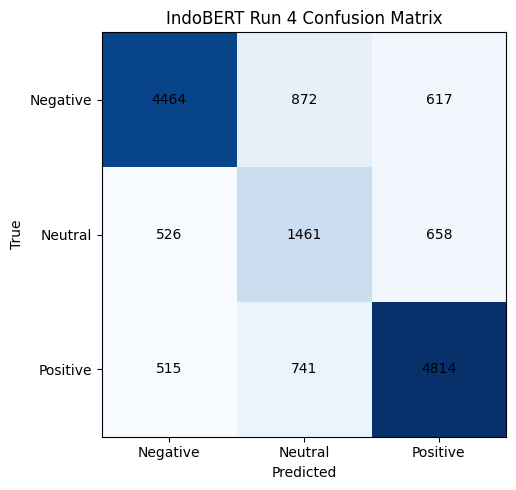

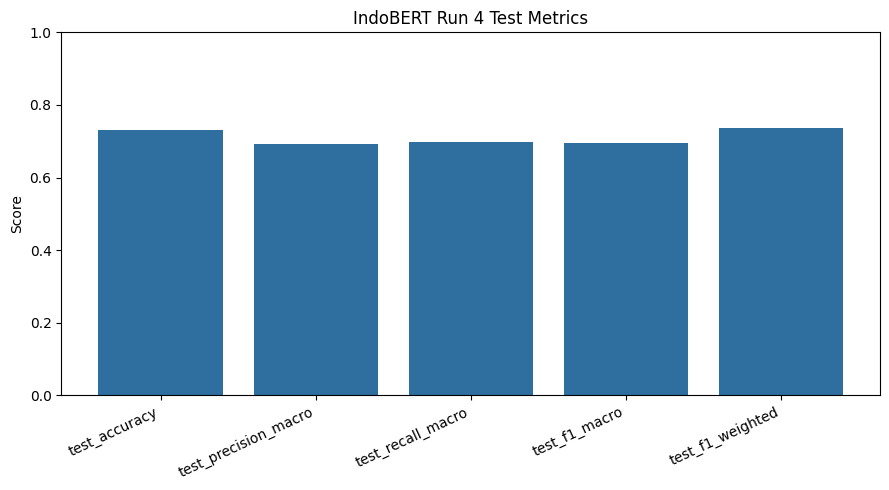

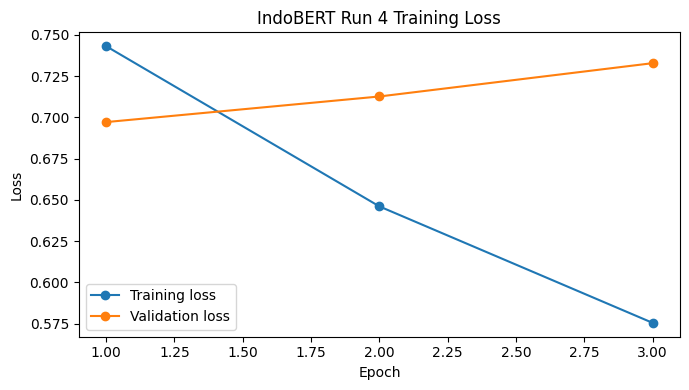

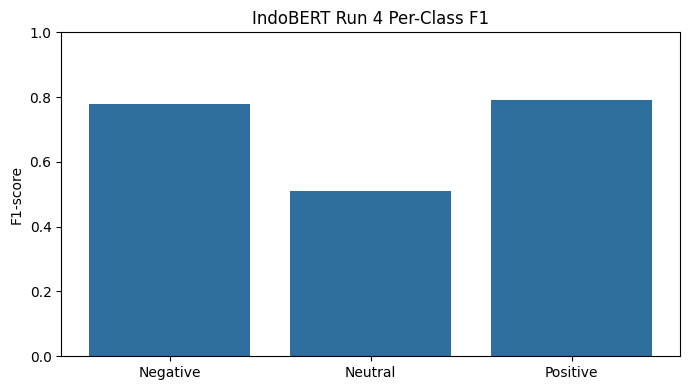

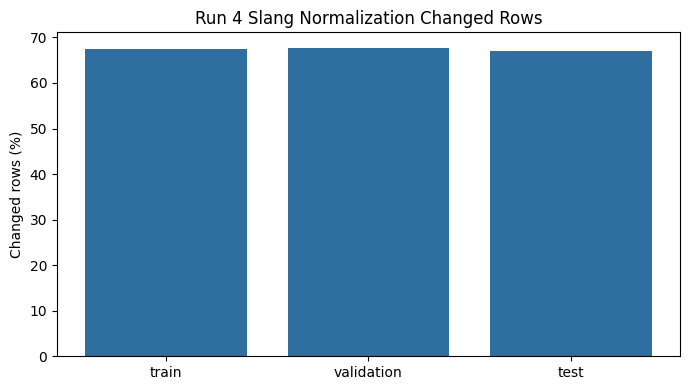

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.imshow(confusion_matrix_data, cmap="Blues")
plt.title("IndoBERT Run 4 Confusion Matrix")
plt.xticks([0, 1, 2], [id2label[0], id2label[1], id2label[2]])
plt.yticks([0, 1, 2], [id2label[0], id2label[1], id2label[2]])
plt.xlabel("Predicted")
plt.ylabel("True")
for row_index in range(confusion_matrix_data.shape[0]):
    for column_index in range(confusion_matrix_data.shape[1]):
        plt.text(column_index, row_index, confusion_matrix_data[row_index, column_index], ha="center", va="center")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "indobert_confusion_matrix.png", dpi=160)
plt.show()

metric_names = ["test_accuracy", "test_precision_macro", "test_recall_macro", "test_f1_macro", "test_f1_weighted"]
metric_values = [float(test_metrics.get(name, 0.0)) for name in metric_names]
plt.figure(figsize=(9, 5))
plt.bar(metric_names, metric_values, color="#2f6f9f")
plt.title("IndoBERT Run 4 Test Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "indobert_eval_metrics.png", dpi=160)
plt.show()

loss_points = [(entry.get("epoch"), entry.get("loss")) for entry in trainer.state.log_history if "loss" in entry]
eval_loss_points = [(entry.get("epoch"), entry.get("eval_loss")) for entry in trainer.state.log_history if "eval_loss" in entry]
plt.figure(figsize=(7, 4))
if loss_points:
    epochs, losses = zip(*loss_points)
    plt.plot(epochs, losses, marker="o", label="Training loss")
if eval_loss_points:
    epochs, losses = zip(*eval_loss_points)
    plt.plot(epochs, losses, marker="o", label="Validation loss")
plt.title("IndoBERT Run 4 Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "indobert_training_loss.png", dpi=160)
plt.show()

class_names = [id2label[0], id2label[1], id2label[2]]
class_f1_scores = [classification_report_dict[class_name]["f1-score"] for class_name in class_names]
plt.figure(figsize=(7, 4))
plt.bar(class_names, class_f1_scores, color="#2f6f9f")
plt.title("IndoBERT Run 4 Per-Class F1")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "indobert_class_f1_score.png", dpi=160)
plt.show()

changed_rows_df = pd.DataFrame(slang_summary["split_summaries"])
plt.figure(figsize=(7, 4))
plt.bar(changed_rows_df["split"], changed_rows_df["changed_percentage"], color="#2f6f9f")
plt.title("Run 4 Slang Normalization Changed Rows")
plt.ylabel("Changed rows (%)")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "indobert_slang_changed_rows.png", dpi=160)
plt.show()


## Multi-run Comparison Section
Load Run 1, Run 2, and Run 3 outputs if available. Compare Run 1, Run 2, Run 3, and Run 4 on accuracy, macro F1, weighted F1, Negative F1, Neutral precision, Neutral recall, Neutral F1, and Positive F1. Skip safely if previous run files are missing.

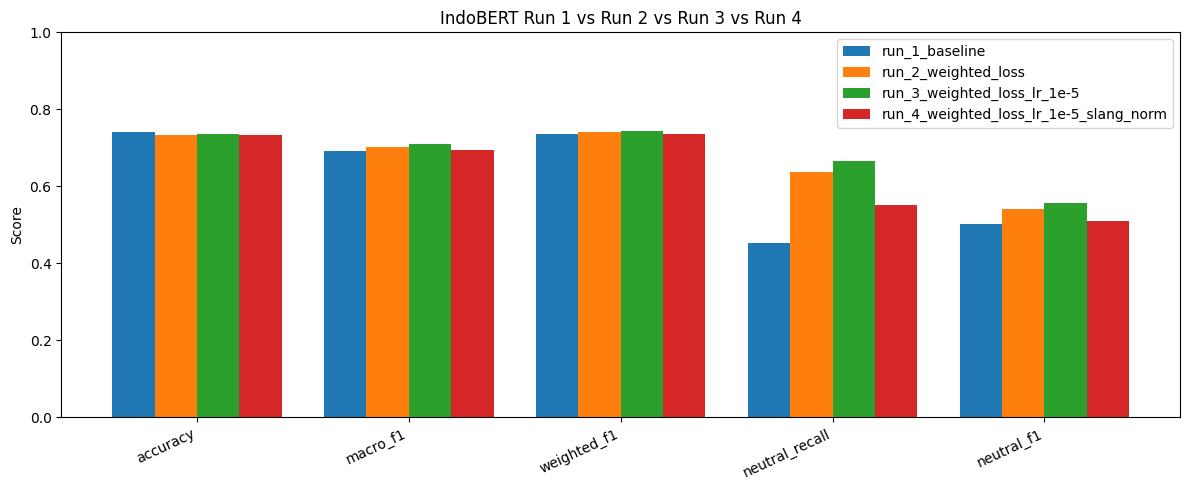

In [ ]:
def load_run_summary(run_name: str, output_dir: Path):
    metrics_file = output_dir / "indobert_training_metrics.json"
    report_file = output_dir / "indobert_classification_report.json"
    if not metrics_file.is_file() or not report_file.is_file():
        print(f"Skipping {run_name}: missing metrics or classification report.")
        return None
    metrics = json.loads(metrics_file.read_text(encoding="utf-8"))
    report = json.loads(report_file.read_text(encoding="utf-8"))
    test_metrics_data = metrics.get("test_metrics", {})
    return {
        "run_name": run_name,
        "accuracy": test_metrics_data.get("test_accuracy", test_metrics_data.get("accuracy")),
        "macro_f1": test_metrics_data.get("test_f1_macro", test_metrics_data.get("f1_macro")),
        "weighted_f1": test_metrics_data.get("test_f1_weighted", test_metrics_data.get("f1_weighted")),
        "negative_f1": report["Negative"]["f1-score"],
        "neutral_precision": report["Neutral"]["precision"],
        "neutral_recall": report["Neutral"]["recall"],
        "neutral_f1": report["Neutral"]["f1-score"],
        "positive_f1": report["Positive"]["f1-score"],
    }

comparison_rows = []
for run_name, run_output_dir in RUN_OUTPUT_DIRS.items():
    row = load_run_summary(run_name, run_output_dir)
    if row is not None:
        comparison_rows.append(row)

comparison_rows.append(
    {
        "run_name": RUN_NAME,
        "accuracy": test_metrics.get("test_accuracy"),
        "macro_f1": test_metrics.get("test_f1_macro"),
        "weighted_f1": test_metrics.get("test_f1_weighted"),
        "negative_f1": classification_report_dict["Negative"]["f1-score"],
        "neutral_precision": classification_report_dict["Neutral"]["precision"],
        "neutral_recall": classification_report_dict["Neutral"]["recall"],
        "neutral_f1": classification_report_dict["Neutral"]["f1-score"],
        "positive_f1": classification_report_dict["Positive"]["f1-score"],
    }
)

if len(comparison_rows) >= 2:
    comparison_df = pd.DataFrame(comparison_rows)
    comparison_df.to_csv(OUTPUT_DIR / "indobert_run_comparison.csv", index=False)
    (OUTPUT_DIR / "indobert_run_comparison.json").write_text(
        comparison_df.to_json(orient="records", indent=2), encoding="utf-8"
    )
    plot_metrics = ["accuracy", "macro_f1", "weighted_f1", "neutral_recall", "neutral_f1"]
    x_positions = np.arange(len(plot_metrics))
    width = 0.8 / len(comparison_df)
    plt.figure(figsize=(12, 5))
    for row_index, (_, row) in enumerate(comparison_df.iterrows()):
        offset = (row_index - (len(comparison_df) - 1) / 2) * width
        plt.bar(x_positions + offset, row[plot_metrics], width=width, label=row["run_name"])
    plt.title("IndoBERT Run 1 vs Run 2 vs Run 3 vs Run 4")
    plt.ylabel("Score")
    plt.ylim(0, 1)
    plt.xticks(x_positions, plot_metrics, rotation=25, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "indobert_run_comparison.png", dpi=160)
    plt.show()
    comparison_df
else:
    print("Previous run files were not available; multi-run comparison skipped.")


## Decision Rule Section
Select the final IndoBERT candidate based on: highest macro F1, improved Neutral F1 and Neutral recall, accuracy not dropping too far, stable Negative and Positive F1, and no severe overfitting based on validation history.

## Interpretation Section
After training, document whether slang normalization improved macro F1, whether it improved the Neutral precision/recall trade-off, whether it reduced errors on informal or slang-heavy texts, whether Run 4 should replace Run 3 as the candidate final model, and what limitations remain.

## Local Repository Sync Note
Copy small Run 4 metrics to `datasets/outputs/eda/03_indobert/run_4_weighted_loss_lr_1e-5_slang_norm/` and figures to `docs/figures/03_indobert/run_4_weighted_loss_lr_1e-5_slang_norm/`. Do not commit `saved_model/`, checkpoints, `model.safetensors`, `pytorch_model.bin`, or large prediction files if they are too large for the repository policy.

## Next Step
Compare Run 1, Run 2, Run 3, and Run 4. If Run 4 improves macro F1 or gives a better Neutral trade-off, use Run 4 as the candidate final model. If Run 4 does not improve, keep Run 3 as the candidate final model. Then proceed to final IndoBERT evaluation documentation.